# **Tehran House Price Regression**

In [1]:
import warnings
warnings.filterwarnings('ignore')


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
import joblib

# 1) Load data

In [3]:
DATA_PATH = '/mnt/data/1632300362534233.csv'

In [12]:
df = pd.read_csv("1632300362534233.csv")
print("Initial shape:", df.shape)
print("\nData Info:")
print(df.info())
print("\nColumn dtypes:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())


Initial shape: (3479, 8)

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3479 entries, 0 to 3478
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Area        3479 non-null   object 
 1   Room        3479 non-null   int64  
 2   Parking     3479 non-null   bool   
 3   Warehouse   3479 non-null   bool   
 4   Elevator    3479 non-null   bool   
 5   Address     3456 non-null   object 
 6   Price       3479 non-null   int64  
 7   Price(USD)  3479 non-null   float64
dtypes: bool(3), float64(1), int64(2), object(2)
memory usage: 146.2+ KB
None

Column dtypes:
Area           object
Room            int64
Parking          bool
Warehouse        bool
Elevator         bool
Address        object
Price           int64
Price(USD)    float64
dtype: object

Missing values:
Area           0
Room           0
Parking        0
Warehouse      0
Elevator       0
Address       23
Price          0
Price(USD)     0
dtype: int

# 2) Data cleaning

Convert numeric columns from string to numeric, handling errors

In [29]:
numeric_columns_to_convert = ["Area", "Room", "Parking", "Warehouse", "Elevator", "Price", "Price(USD)"]

for col in numeric_columns_to_convert:
    if col in df.columns:
        print(f"\nConverting {col} to numeric...")
        # Convert to numeric, forcing errors to NaN
        df[col] = pd.to_numeric(df[col], errors='coerce')
        print(f"Missing values in {col} after conversion: {df[col].isnull().sum()}")

print("\nData types after conversion:")
print(df.dtypes)


Converting Area to numeric...
Missing values in Area after conversion: 0

Converting Room to numeric...
Missing values in Room after conversion: 0

Converting Parking to numeric...
Missing values in Parking after conversion: 0

Converting Warehouse to numeric...
Missing values in Warehouse after conversion: 0

Converting Elevator to numeric...
Missing values in Elevator after conversion: 0

Converting Price to numeric...
Missing values in Price after conversion: 0

Converting Price(USD) to numeric...
Missing values in Price(USD) after conversion: 0

Data types after conversion:
Area          float64
Room            int64
Parking          bool
Warehouse        bool
Elevator         bool
Address        object
Price           int64
Price(USD)    float64
dtype: object


Drop rows without Address

In [30]:
df = df.dropna(subset=["Address"])

Remove rows with missing numeric values in key columns

In [31]:
df = df.dropna(subset=["Area", "Price", "Price(USD)"])


After cleaning: (2703, 8)

Descriptive statistics after cleaning:
              Area         Room         Price     Price(USD)
count  2703.000000  2703.000000  2.703000e+03    2703.000000
mean     88.049575     1.901591  2.880198e+09   96006.609993
std      33.997994     0.623920  2.097582e+09   69919.383543
min      30.000000     0.000000  3.600000e+06     120.000000
25%      65.000000     2.000000  1.200000e+09   40000.000000
50%      85.000000     2.000000  2.300000e+09   76666.670000
75%     105.000000     2.000000  3.974000e+09  132466.670000
max     465.000000     5.000000  8.700000e+09  290000.000000


Remove unrealistic Area values (now that it's numeric)

In [34]:
df = df[(df["Area"] > 20) & (df["Area"] < 500)]


After cleaning: (2644, 8)

Descriptive statistics after cleaning:
              Area         Room         Price     Price(USD)
count  2644.000000  2644.000000  2.644000e+03    2644.000000
mean     87.256051     1.890696  2.756081e+09   91869.377266
std      33.782862     0.619830  1.947172e+09   64905.725915
min      30.000000     0.000000  3.600000e+06     120.000000
25%      65.000000     2.000000  1.150075e+09   38335.835000
50%      84.000000     2.000000  2.280000e+09   76000.000000
75%     103.000000     2.000000  3.852250e+09  128408.330000
max     465.000000     5.000000  8.100000e+09  270000.000000


Remove outliers using IQR method for Price

In [35]:
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1
df = df[~((df['Price'] < (Q1 - 1.5 * IQR)) | (df['Price'] > (Q3 + 1.5 * IQR)))]

Drop duplicates

In [36]:
df = df.drop_duplicates()

print(f"\nAfter cleaning: {df.shape}")
print("\nDescriptive statistics after cleaning:")
print(df[["Area", "Room", "Price", "Price(USD)"]].describe())


After cleaning: (2619, 8)

Descriptive statistics after cleaning:
              Area         Room         Price     Price(USD)
count  2619.000000  2619.000000  2.619000e+03    2619.000000
mean     86.841161     1.883162  2.705729e+09   90190.963517
std      33.596889     0.616258  1.886642e+09   62888.061404
min      30.000000     0.000000  3.600000e+06     120.000000
25%      65.000000     2.000000  1.147500e+09   38250.000000
50%      84.000000     2.000000  2.250000e+09   75000.000000
75%     102.000000     2.000000  3.800000e+09  126666.670000
max     465.000000     5.000000  7.900000e+09  263333.330000


# 3) Address feature engineering 

Define numeric columns for analysis


Numeric columns: ['Area', 'Room', 'Price', 'Price(USD)']


<Figure size 1000x800 with 0 Axes>

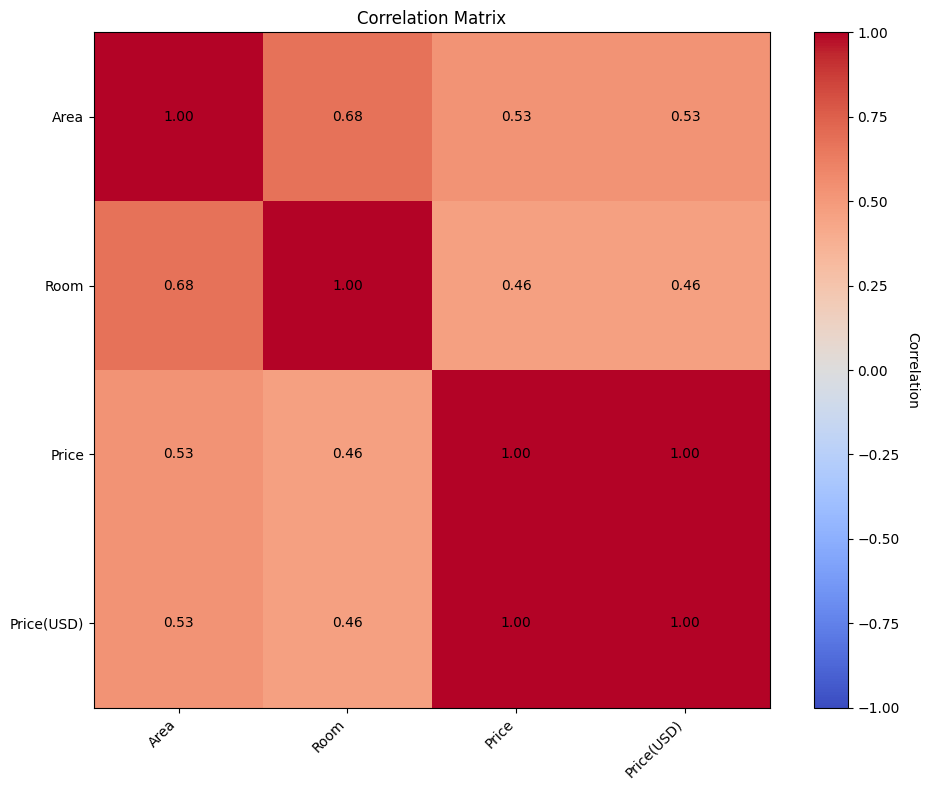

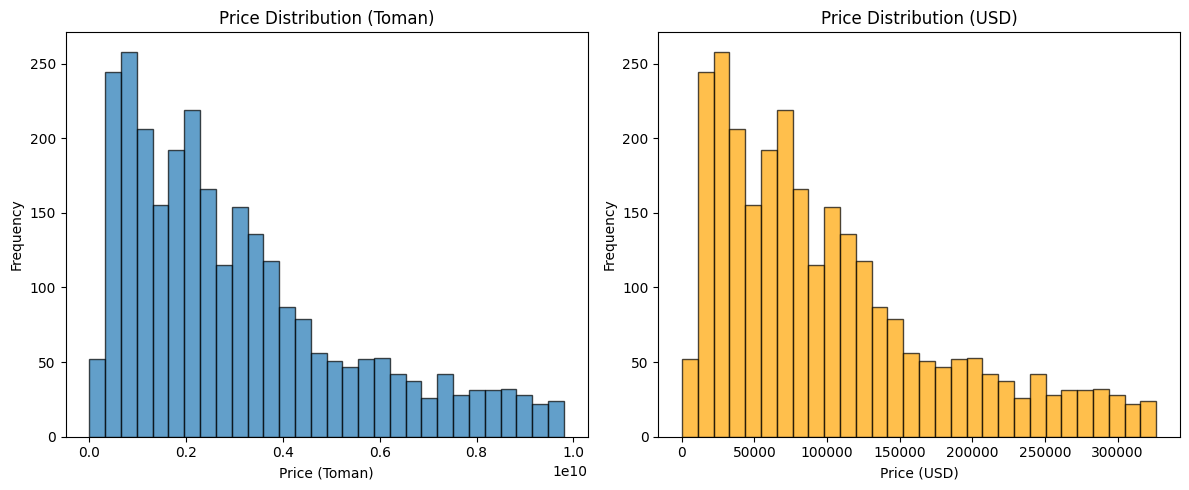

In [18]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nNumeric columns: {numeric_cols}")

# Correlation analysis
plt.figure(figsize=(10, 8))
correlation_matrix = df[numeric_cols].corr()

# Create correlation plot using matplotlib
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1)

# Add colorbar
cbar = ax.figure.colorbar(im, ax=ax)
cbar.ax.set_ylabel('Correlation', rotation=-90, va="bottom")

# Set ticks and labels
ax.set_xticks(np.arange(len(numeric_cols)))
ax.set_yticks(np.arange(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=45, ha="right")
ax.set_yticklabels(numeric_cols)

# Add correlation values as text
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        text = ax.text(j, i, f'{correlation_matrix.iloc[i, j]:.2f}',
                       ha="center", va="center", color="black")

ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()

# Distribution of prices
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df['Price'], bins=30, alpha=0.7, edgecolor='black')
plt.xlabel('Price (Toman)')
plt.ylabel('Frequency')
plt.title('Price Distribution (Toman)')

plt.subplot(1, 2, 2)
plt.hist(df['Price(USD)'], bins=30, alpha=0.7, edgecolor='black', color='orange')
plt.xlabel('Price (USD)')
plt.ylabel('Frequency')
plt.title('Price Distribution (USD)')

plt.tight_layout()
plt.show()

# 4) Features and labels

In [19]:
X = df[["Area", "Room", "Parking", "Warehouse", "Elevator", "Address"]]
y_toman = df["Price"]
y_usd = df["Price(USD)"]

X_train, X_test, y_t_train, y_t_test, y_u_train, y_u_test = train_test_split(
    X, y_toman, y_usd, test_size=0.2, random_state=42
)

print(f"\nTraining set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")


Training set size: (2226, 6)
Test set size: (557, 6)


# 5) Preprocessing (LinearRegression)

In [23]:
numeric_features = ["Area", "Room"]
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_features = ["Parking", "Warehouse", "Elevator", "Address"]
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# 6) Modeling

In [24]:
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1),
    "RandomForest": RandomForestRegressor(random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(random_state=42)
}

def evaluate_and_save(X_train, X_test, y_train, y_test, target_name):
    best_rmse = float("inf")
    best_model = None
    best_model_name = ""
    
    results = {}
    
    for name, model in models.items():
        try:
            pipe = Pipeline(steps=[("preproc", preprocessor), ("model", model)])
            
            # Cross-validation
            cv_scores = cross_val_score(pipe, X_train, y_train, 
                                       cv=5, scoring='neg_mean_squared_error')
            
            # Train and predict
            pipe.fit(X_train, y_train)
            y_pred = pipe.predict(X_test)

            mae = mean_absolute_error(y_test, y_pred)
            
            # حساب RMSE يدوياً للإصدارات القديمة من scikit-learn
            mse = mean_squared_error(y_test, y_pred)
            rmse = np.sqrt(mse)
            
            r2 = r2_score(y_test, y_pred)

            print(f"{name} ({target_name}) -> MAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.2f}")
            
            # حساب RMSE لل cross-validation
            cv_rmse = np.sqrt(-cv_scores.mean())
            cv_std = np.sqrt(cv_scores.std()) * 2
            print(f"CV RMSE: {cv_rmse:.2f} (±{cv_std:.2f})")

            if rmse < best_rmse:
                best_rmse = rmse
                best_model = pipe
                best_model_name = name
                
            results[name] = {
                'mae': mae,
                'rmse': rmse,
                'r2': r2,
                'cv_rmse': cv_rmse
            }
            
        except Exception as e:
            print(f"Error with {name}: {str(e)}")
            continue

    # Save best model
    if best_model is not None:
        joblib.dump(best_model, f"best_model_{target_name}.joblib")
        print(f"Best model for {target_name}: {best_model_name} with RMSE: {best_rmse:.2f}\n")
    else:
        print(f"No successful models for {target_name}\n")
    
    return best_model, results

# Evaluate models for both target variables
print("Evaluating models for Toman...")
best_toman, results_toman = evaluate_and_save(X_train, X_test, y_t_train, y_t_test, "toman")

print("Evaluating models for USD...")
best_usd, results_usd = evaluate_and_save(X_train, X_test, y_u_train, y_u_test, "usd")

Evaluating models for Toman...
LinearRegression (toman) -> MAE: 697661079.91, RMSE: 1040273355.05, R²: 0.82
CV RMSE: 1155889867.79 (±751114040.57)
Ridge (toman) -> MAE: 728657732.52, RMSE: 1080561218.43, R²: 0.81
CV RMSE: 1144507943.07 (±766199077.68)
Lasso (toman) -> MAE: 697661081.28, RMSE: 1040279089.98, R²: 0.82
CV RMSE: 1155650856.67 (±747987306.85)
RandomForest (toman) -> MAE: 693702139.00, RMSE: 1105630220.01, R²: 0.80
CV RMSE: 1167712510.79 (±927768295.29)
GradientBoosting (toman) -> MAE: 797482254.71, RMSE: 1165875277.97, R²: 0.78
CV RMSE: 1195327219.93 (±875793601.68)
Best model for toman: LinearRegression with RMSE: 1040273355.05

Evaluating models for USD...
LinearRegression (usd) -> MAE: 23255.37, RMSE: 34675.78, R²: 0.82
CV RMSE: 38529.66 (±25037.13)
Ridge (usd) -> MAE: 24288.59, RMSE: 36018.71, R²: 0.81
CV RMSE: 38150.26 (±25539.97)
Lasso (usd) -> MAE: 23259.63, RMSE: 34722.88, R²: 0.82
CV RMSE: 38492.02 (±24916.09)
RandomForest (usd) -> MAE: 23085.55, RMSE: 36801.45, R²

# 7) Plot predictions vs actual (Toman)

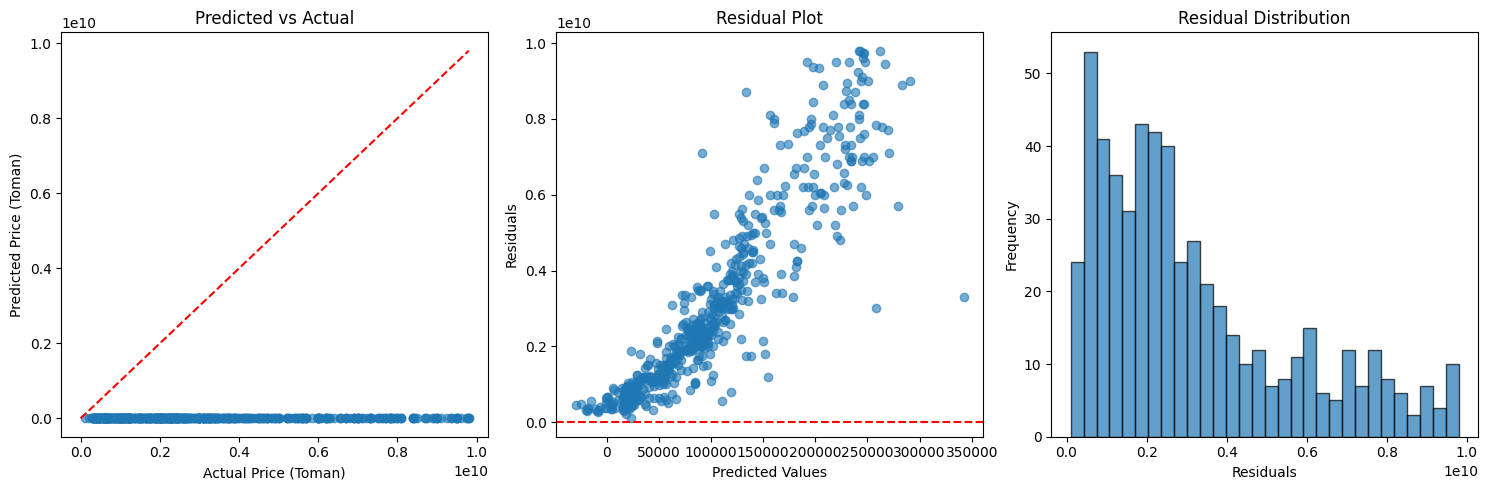

In [25]:
def plot_predictions(y_true, y_pred, target_name):
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.scatter(y_true, y_pred, alpha=0.6)
    max_val = max(y_true.max(), y_pred.max())
    min_val = min(y_true.min(), y_pred.min())
    plt.plot([min_val, max_val], [min_val, max_val], "r--")
    plt.xlabel(f"Actual Price ({target_name})")
    plt.ylabel(f"Predicted Price ({target_name})")
    plt.title("Predicted vs Actual")
    
    plt.subplot(1, 3, 2)
    residuals = y_true - y_pred
    plt.scatter(y_pred, residuals, alpha=0.6)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.xlabel("Predicted Values")
    plt.ylabel("Residuals")
    plt.title("Residual Plot")
    
    plt.subplot(1, 3, 3)
    plt.hist(residuals, bins=30, alpha=0.7, edgecolor='black')
    plt.xlabel("Residuals")
    plt.ylabel("Frequency")
    plt.title("Residual Distribution")
    
    plt.tight_layout()
    plt.show()

# Plot predictions for Toman
if best_toman is not None:
    pred_toman = best_toman.predict(X_test)
    plot_predictions(y_t_test, pred_toman, "Toman")

# 8) Example prediction

In [26]:
if best_toman is not None and hasattr(best_toman.named_steps['model'], 'feature_importances_'):
    try:
        # Get feature names from the preprocessor
        numeric_features = numeric_features
        categorical_features_full = (best_toman.named_steps['preproc']
                                   .named_transformers_['cat']
                                   .named_steps['onehot']
                                   .get_feature_names_out(categorical_features))
        
        feature_names = numeric_features + list(categorical_features_full)
        importances = best_toman.named_steps['model'].feature_importances_
        
        feat_imp = pd.DataFrame({'feature': feature_names, 'importance': importances})
        feat_imp = feat_imp.sort_values('importance', ascending=False)
        
        plt.figure(figsize=(12, 8))
        plt.barh(feat_imp.head(15)['feature'], feat_imp.head(15)['importance'])
        plt.xlabel('Importance')
        plt.ylabel('Feature')
        plt.title('Feature Importance')
        plt.gca().invert_yaxis()  # Most important at the top
        plt.tight_layout()
        plt.show()
        
        print("Top 10 most important features:")
        print(feat_imp.head(10))
        
    except Exception as e:
        print(f"Could not plot feature importance: {e}")

# 9) Suggestions for improvement

In [27]:
if best_toman is not None and best_usd is not None:
    sample = pd.DataFrame([{
        "Area": 90, "Room": 2, "Parking": 1,
        "Warehouse": 0, "Elevator": 1, "Address": "Vanak"
    }])

    toman_pred = best_toman.predict(sample)[0]
    usd_pred = best_usd.predict(sample)[0]

    print(f"\nSample Prediction:")
    print(f"Area: 90m², Rooms: 2, Address: Vanak")
    print(f"Predicted Price (Toman): {toman_pred:,.0f}")
    print(f"Predicted Price (USD): {usd_pred:,.0f}")


Sample Prediction:
Area: 90m², Rooms: 2, Address: Vanak
Predicted Price (Toman): 106,618
Predicted Price (USD): 106,618


# 10) Model Comparison

In [28]:
def compare_models(results, target_name):
    comparison = pd.DataFrame(results).T
    if not comparison.empty:
        comparison = comparison.sort_values('rmse')
        print(f"\nModel Comparison for {target_name}:")
        print(comparison[['rmse', 'r2', 'cv_rmse']].round(2))
    else:
        print(f"\nNo results to compare for {target_name}")

compare_models(results_toman, "Toman")
compare_models(results_usd, "USD")

print("\nAnalysis complete!")


Model Comparison for Toman:
                          rmse    r2       cv_rmse
LinearRegression  1.040273e+09  0.82  1.155890e+09
Lasso             1.040279e+09  0.82  1.155651e+09
Ridge             1.080561e+09  0.81  1.144508e+09
RandomForest      1.105630e+09  0.80  1.167713e+09
GradientBoosting  1.165875e+09  0.78  1.195327e+09

Model Comparison for USD:
                      rmse    r2   cv_rmse
LinearRegression  34675.78  0.82  38529.66
Lasso             34722.88  0.82  38492.02
Ridge             36018.71  0.81  38150.26
RandomForest      36801.45  0.80  38965.27
GradientBoosting  38862.51  0.78  39834.11

Analysis complete!
